## Lasso
我们在做普通的线性回归时，时常会遇到模型**过拟合**，导致预测结果并不尽人意的情况，和岭回归相同，我们可以考虑在原先的RSS损失函数后面再加上一项限制系数的惩罚项,得到新的损失函数，表达式如下所示（表达式默认都省略偏置项）
$$J(w) = ||y - X w||^2 + \alpha \sum_{j = 1}^{p} |w_j|$$
其中 $\alpha \sum_{j = 1}^{p} |w_j|$ 称为 L1正则化项。关于这一项，一方面，他在限制参数大小的同时还兼具了**特征选择**的作用；另一方面由于该项在 $w_j = 0$ 处不可导，我们并不能像岭回归那样通过梯度等于零的方式来获得解析解，而是使用迭代优化算法（这不是我们的重点，故不展开），这会使得解并不如岭回归那么稳定

#### **关键超参数**
和岭回归类似，Lasso 由于 L1 正则化项的存在，使我们获得了两个很关键超参数
1. **`alpha`：特征选择的强度**

控制L1惩罚项的强度，alpha越大，被压缩为0的系数越多，模型越稀疏

2. **`max_iter`：迭代求解上限**

迭代优化的最大迭代次数，如出现收敛警告，则可增大该项

问题：
我们选择和岭回归相同的数据集（diabetes）,方便对二者结果进行比较

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

### **1.导入并观察数据集的基本情况**

In [14]:
diabetes = load_diabetes()
print(diabetes['DESCR'])
df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
print(df)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### **2.划分训练集和验证集**

In [15]:
X = diabetes.data
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### **3.数据进行标准化处理**
和岭回归一样，对于 Lasso 来说，系数的大小天然与其对应的特征值的尺度相关，而 L1 正则化项的惩罚力度确是统一的，所以数据的标准化处理仍然是必要的

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **4.训练模型并进行预测**

In [17]:
from sklearn.model_selection import GridSearchCV

lasso = Lasso()
param_grid = {'alpha': [1, 10, 100, 1000],
              'max_iter': [100, 1000, 10000]}
grid_searcher = GridSearchCV(estimator = lasso,
                             param_grid = param_grid,
                             cv = 5,    #做 5 次交叉验证
                             scoring = 'r2',
                             n_jobs = -1    #使用所有 cpu 核心进行并行运算
                             )

grid_searcher.fit(X_train, y_train)
print(f"最佳参数：{grid_searcher.best_params_}")
print(f"最佳交叉验证分数：{grid_searcher.best_score_}")

best_ridge = grid_searcher.best_estimator_
y_pred = best_ridge.predict(X_test)

最佳参数：{'alpha': 1, 'max_iter': 100}
最佳交叉验证分数：0.5279647956489787


### **5.对结果进行评估**

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}  (越小越好)")
print(f"RMSE: {rmse:.2f}  (越小越好，和 y 同单位)")
print(f"MAE:  {mae:.2f}  (越小越好，对异常值不敏感)")
print(f"R²:   {r2:.3f}  (越接近 1 越好)")

MSE: 3412.66  (越小越好)
RMSE: 58.42  (越小越好，和 y 同单位)
MAE:  46.04  (越小越好，对异常值不敏感)
R²:   0.334  (越接近 1 越好)


### **6.预测结果可视化**

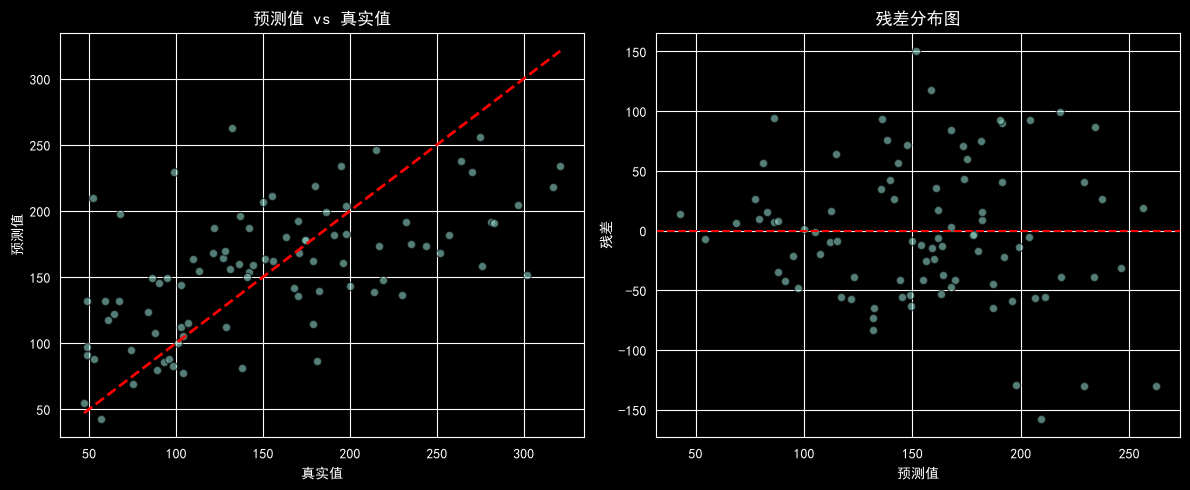

In [19]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左图：预测值 vs 真实值
ax1.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('真实值')
ax1.set_ylabel('预测值')
ax1.set_title('预测值 vs 真实值')

# 右图：残差分布
ax2.scatter(y_pred, residuals, alpha=0.6, edgecolors='k')
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('预测值')
ax2.set_ylabel('残差')
ax2.set_title('残差分布图')

plt.tight_layout()
plt.savefig('ridge_pred_residual.png', dpi=200, bbox_inches='tight')
plt.show()